# Runx3 OE in Arm/Clone13

## Statistical Analysis of Flow Data
**Dataset:** The Scripps Research Institute\Lab 2021\Flow\Albao2022-01-25-Runx3OEReplicate

## Initialize Environment

In [1]:
# Load Packages
library(fcexpr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(ggsci)
library(stringr)
library(jsonlite)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘jsonlite’ was built under R version 4.4.3”


In [2]:
# Set Working Directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig06")

# Load flow processing functions
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Output Folder
output_folder <- "2022-001"

# Load Workspace (or cached version if it exists)
workspace <- load_workspace_cached(
                wsp_file = "2022-001-260830-ReAnalysis-Runx3OE-ArmClone13.wsp",
                rds_file = "2022-001-Workspace.rds",
                overwrite = FALSE # Set to TRUE to reprocess WSP and overwrite cached workspace
        )

# Extract Counts and MFI
counts <- workspace[["counts"]]
stats  <- workspace[["stats"]]


Attaching package: ‘rlang’


The following objects are masked from ‘package:jsonlite’:

    flatten, unbox



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘purrr’


The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice


The following object is masked from ‘package:jsonlite’:

    flatten




# Process Gating Data
Cleanup data to report only gates below CD8/Transferred, restricted to the two real FlowJo sample groups ("Arm" and "Chronic"; "Concatenated" reference files are dropped).

In [3]:
# Keep only the per-mouse sample groups, rename FileName to ID,
# and give the FlowJoGroup a manuscript-friendly Group label
surface <- counts %>%
    filter(FlowJoGroup %in% c("Arm", "Chronic")) %>%
    rename(ID = FileName) %>%
    mutate(Group = recode(FlowJoGroup, "Arm" = "Armstrong", "Chronic" = "Clone 13"))

# Keep only gates below CD8/Transferred, and relevel PopulationFullPath
# so it reads as Condition[/Population], e.g. "mock" or "mock/DP"
surface <- surface %>%
    filter(grepl("Lymphocytes/Single Cells/Single Cells/Live/CD8/Transferred/", PopulationFullPath)) %>%
    mutate(PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/Live/CD8/Transferred/", "", PopulationFullPath))

# Multiply FractionOfParent by 100 and rename to Percent
surface <- surface %>%
    mutate(Percent = FractionOfParent * 100) %>%
    select(ID, Group, PopulationFullPath, Count, Percent)

head(surface)

,ID,Group,PopulationFullPath,Count,Percent
,<chr>,<chr>,<chr>,<dbl>,<dbl>
192,Acute_AcuteD8M1.fcs,Armstrong,mock,3701,3.690703
193,Acute_AcuteD8M1.fcs,Armstrong,naive,22987,22.923045
194,Acute_AcuteD8M1.fcs,Armstrong,Runx3,11199,11.167842
195,Acute_AcuteD8M1.fcs,Armstrong,mock/DP,352,9.510943
196,Acute_AcuteD8M1.fcs,Armstrong,mock/EE,294,7.943799
197,Acute_AcuteD8M1.fcs,Armstrong,mock/eTcm,43,1.161848


Calculate total percent:

In [4]:
# Compute Percent of Total (percent of CD8/Transferred), keep the raw
# PopulationFullPath as PopulationString for the later MFI join, and
# set the Condition-level row's own Percent to 100 (it is 100% of itself)
total_percent <- surface %>%
    compute_percent_of_total() %>%
    mutate(
        PopulationString = PopulationFullPath,
        Percent = ifelse(Depth == 1, 100, Percent)
    ) %>%
    add_population_derivatives() %>%
    finalize_flow_table(round_digits = NULL) %>%
    # Population (from add_population_derivatives) is the Condition
    # (mock/naive/Runx3); Population1Deriv is the actual gated Population
    rename(Condition = Population, PercentOfTransferred = PercentOfTotal) %>%
    mutate(Population = ifelse(is.na(Population1Deriv), "all", Population1Deriv)) %>%
    select(-Population1Deriv)

head(total_percent, n = 10)

ID,Group,Condition,Count,PopulationString,Percent,PercentOfTransferred,Population
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
Acute_AcuteD8M1.fcs,Armstrong,Runx3,11199,Runx3,100.0000000,11.16784172,all
Acute_AcuteD8M1.fcs,Armstrong,Runx3,4863,Runx3/DP,43.4235200,4.84946998,DP
Acute_AcuteD8M1.fcs,Armstrong,Runx3,804,Runx3/EE,7.1792124,0.80176308,EE
Acute_AcuteD8M1.fcs,Armstrong,Runx3,1231,Runx3/ExhKLRG1,10.9920529,1.22757507,ExhKLRG1
Acute_AcuteD8M1.fcs,Armstrong,Runx3,43,Runx3/Hi,0.3839629,0.04288036,Hi
Acute_AcuteD8M1.fcs,Armstrong,Runx3,5460,Runx3/Int,48.7543531,5.44480898,Int
Acute_AcuteD8M1.fcs,Armstrong,Runx3,5418,Runx3/Lo,48.3793196,5.40292584,Lo
Acute_AcuteD8M1.fcs,Armstrong,Runx3,3433,Runx3/MP,30.6545227,3.42344858,MP
Acute_AcuteD8M1.fcs,Armstrong,Runx3,6800,Runx3/NonterminalKLRG1,60.7197071,6.78108078,NonterminalKLRG1


Derive KLRG1+ (TE + DP) and CD127+ (DP + MP) from the mutually exclusive Kaech gates, using `combinePercents()`:

In [5]:
# combinePercents operates on wide format (one column per PopulationFullPath),
# so pivot Percent wide first
percent_wide <- total_percent %>%
    select(ID, Group, PopulationString, Percent) %>%
    pivot_wider(names_from = PopulationString, values_from = Percent)

kaech_conditions <- c("mock", "naive", "Runx3")

for (cond in kaech_conditions) {
    percent_wide <- combinePercents(
        percent_wide,
        resultingPath = "KLRG1pos", Path1 = "TE", Path2 = "DP",
        constantPath = paste0(cond, "/"),
        subsets = character(0) # no further nested subsets under these gates
    )
    percent_wide <- combinePercents(
        percent_wide,
        resultingPath = "CD127pos", Path1 = "DP", Path2 = "MP",
        constantPath = paste0(cond, "/"),
        subsets = character(0)
    )
}

# Pivot the derived populations back to long format and append to total_percent
new_paths <- as.vector(outer(kaech_conditions, c("KLRG1pos", "CD127pos"), FUN = function(c, p) paste0(c, "/", p)))

combined_percent <- percent_wide %>%
    select(ID, Group, all_of(new_paths)) %>%
    pivot_longer(cols = all_of(new_paths), names_to = "PopulationString", values_to = "Percent") %>%
    separate(PopulationString, into = c("Condition", "Population"), sep = "/", extra = "merge") %>%
    mutate(
        Count = NA_real_,
        PercentOfTransferred = NA_real_,
        PopulationString = paste0(Condition, "/", Population)
    ) %>%
    select(ID, Group, PopulationString, Count, Percent, PercentOfTransferred, Condition, Population)

total_percent <- bind_rows(total_percent, combined_percent)

head(combined_percent, n = 10)

ID,Group,PopulationString,Count,Percent,PercentOfTransferred,Condition,Population
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Acute_AcuteD8M1.fcs,Armstrong,mock/KLRG1pos,NA,83.97730,NA,mock,KLRG1pos
Acute_AcuteD8M1.fcs,Armstrong,naive/KLRG1pos,NA,78.78366,NA,naive,KLRG1pos
Acute_AcuteD8M1.fcs,Armstrong,Runx3/KLRG1pos,NA,62.16626,NA,Runx3,KLRG1pos
Acute_AcuteD8M1.fcs,Armstrong,mock/CD127pos,NA,17.58984,NA,mock,CD127pos
Acute_AcuteD8M1.fcs,Armstrong,naive/CD127pos,NA,17.33589,NA,naive,CD127pos
Acute_AcuteD8M1.fcs,Armstrong,Runx3/CD127pos,NA,74.07804,NA,Runx3,CD127pos
Acute_AcuteD8M2.fcs,Armstrong,mock/KLRG1pos,NA,63.21218,NA,mock,KLRG1pos
Acute_AcuteD8M2.fcs,Armstrong,naive/KLRG1pos,NA,72.42658,NA,naive,KLRG1pos
Acute_AcuteD8M2.fcs,Armstrong,Runx3/KLRG1pos,NA,53.64798,NA,Runx3,KLRG1pos


## Process MFI Data

In [6]:
mfi <- stats %>%
    # Keep only relevant columns in stats
    select(FileName, PopulationFullPath, channel, value) %>%
    # Relevel PopulationFullPath to "CD8/Transferred"
    mutate(PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/Live/CD8/Transferred/", "", PopulationFullPath)) %>%
    # Rename channels
    mutate(channel = case_when(channel == "Comp-APC-A" ~ "mfi.TOX")) %>%
    # Pivot wider to have one row per FileName and PopulationFullPath, with columns for each channel
    pivot_wider(names_from = channel, values_from = value)

head(mfi)

FileName,PopulationFullPath,mfi.TOX
<chr>,<chr>,<dbl>
Chronic_ChronicD8M5.fcs,mock,619.4576
Chronic_ChronicD8M5.fcs,mock/DP,539.5388
Chronic_ChronicD8M5.fcs,mock/EE,619.5507
Chronic_ChronicD8M5.fcs,mock/eTcm,1428.5717
Chronic_ChronicD8M5.fcs,mock/ExhKLRG1,545.3463
Chronic_ChronicD8M5.fcs,mock/Hi,820.1795


In [7]:
# Combine mfi (FileName, PopulationFullPath) to total_percent (ID, PopulationString)
all.data <- total_percent %>%
    left_join(mfi, by = c("ID" = "FileName", "PopulationString" = "PopulationFullPath")) %>%
    select(ID, Group, Condition, Population, Count, Percent, PercentOfTransferred, mfi.TOX) %>%
    mutate(
        Condition = recode(Condition, "naive" = "unperturbed"),
        Condition = factor(Condition, levels = c("unperturbed", "mock", "Runx3"))
    )

head(all.data, n = 20)

# Save all.data to CSV
if (!dir.exists(output_folder)) {
    dir.create(output_folder)
}
write.csv(all.data, file = paste0(output_folder, "/measured_data.csv"), row.names = FALSE, quote = FALSE)

ID,Group,Condition,Population,Count,Percent,PercentOfTransferred,mfi.TOX
<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Acute_AcuteD8M1.fcs,Armstrong,Runx3,all,11199,100.0000000,11.16784172,362.3818
Acute_AcuteD8M1.fcs,Armstrong,Runx3,DP,4863,43.4235200,4.84946998,363.3907
Acute_AcuteD8M1.fcs,Armstrong,Runx3,EE,804,7.1792124,0.80176308,370.2423
Acute_AcuteD8M1.fcs,Armstrong,Runx3,ExhKLRG1,1231,10.9920529,1.22757507,355.6371
Acute_AcuteD8M1.fcs,Armstrong,Runx3,Hi,43,0.3839629,0.04288036,417.0939
Acute_AcuteD8M1.fcs,Armstrong,Runx3,Int,5460,48.7543531,5.44480898,354.0023
Acute_AcuteD8M1.fcs,Armstrong,Runx3,Lo,5418,48.3793196,5.40292584,371.1201
Acute_AcuteD8M1.fcs,Armstrong,Runx3,MP,3433,30.6545227,3.42344858,372.2369
Acute_AcuteD8M1.fcs,Armstrong,Runx3,NonterminalKLRG1,6800,60.7197071,6.78108078,357.3046


## Plot

In [8]:
# Use theme_bw, base 12, not bold, and remove legend
theme <- theme_bw(
    base_size = 14,
    base_family = "sans"
) +
    theme(
        axis.text = element_text(size = 14, color = "black"),
        axis.title = element_text(size = 14, color = "black"),
        axis.text.x = element_text(size = 12, angle = 45, hjust = 1, vjust = 1, color = "black"),
        axis.text.y = element_text(size = 12, color = "black"),
        axis.title.x = element_blank(),

        # Remove facet strip background + box
        strip.background = element_rect(fill = NA, color = NA),
        strip.text = element_text(color = "black"),

        legend.position = "none",
        plot.title = element_text(size = 12),
        panel.grid = element_blank()
    )

# Condition colors
colors <- c("unperturbed" = "white", "mock" = "#808180", "Runx3" = "#00A087")

# Paired comparisons, referenced against mock
comparisons <- list(c("unperturbed", "mock"), c("mock", "Runx3"))

### TOX MFI

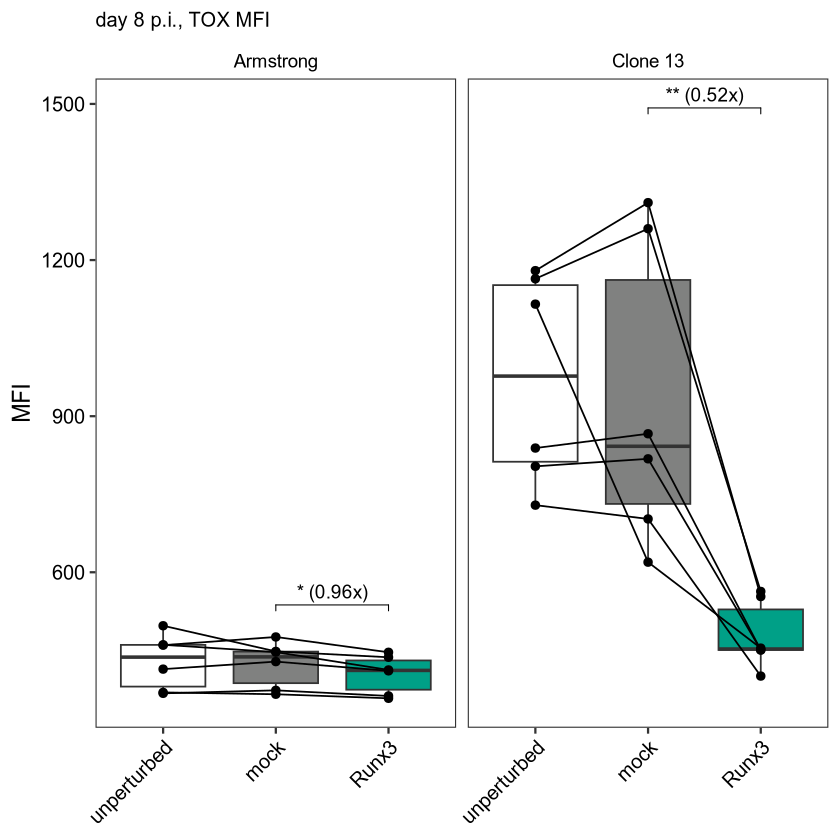

In [9]:
# Subset MFI data on total (Condition-level) populations
tox <- all.data %>% filter(Population == "all")

# Calculate p-values and adjusted p-values for comparisons using plot_padj function
# Comparisons are paired (same mouse across Conditions)
plot.stat.df <- plot_padj(
    data = tox,
    comparisons = comparisons,
    y_col = "mfi.TOX",
    x_col = "Condition",
    facet_col = "Group",
    id_col = "ID",
    paired = TRUE,
    step_fraction = 0.1,
    min_step = 20
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-TOXmfi.csv"), row.names = FALSE)

# Round plot.stat.df column foldmean to one significant digit
# Then concatenate to p.adj.signif only if not "ns", into column p.adj.fold
plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(tox, aes(x = Condition, y = mfi.TOX, fill = Condition)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~Group) +
    scale_fill_manual(values = colors) +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("MFI") + ggtitle("day 8 p.i., TOX MFI")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-TOXmfi.pdf"),
    plot = p,
    width = 5,
    height = 4,
    units = "in"
)

### Kaech-derived Subsets (EE / KLRG1+ / CD127+)

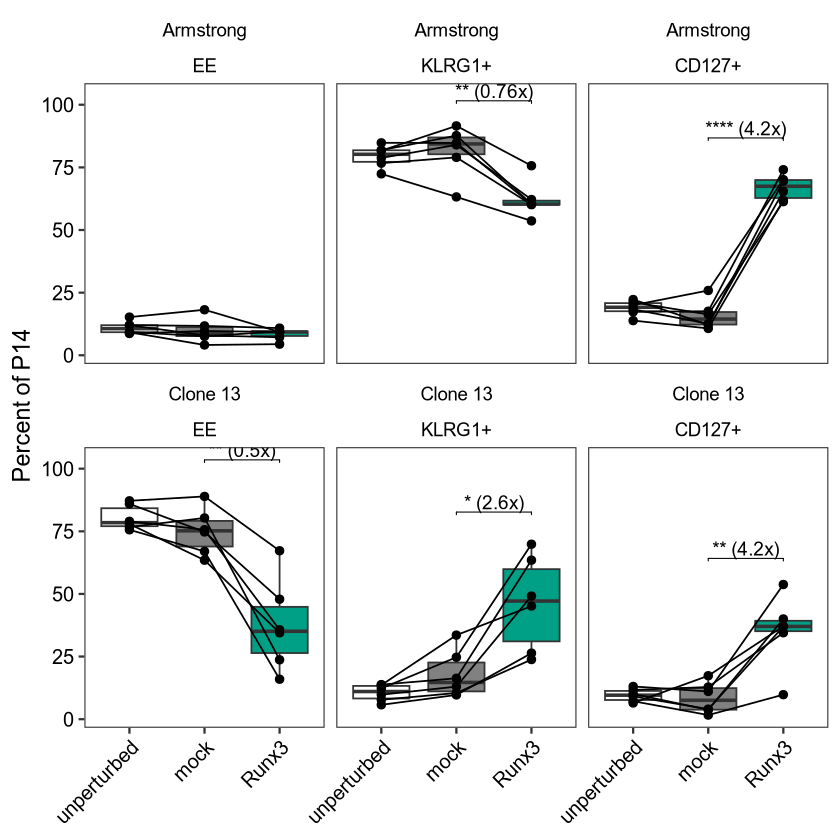

In [10]:
kaech_subsets <- all.data %>%
    filter(Population %in% c("EE", "KLRG1pos", "CD127pos")) %>%
    mutate(Population = factor(
        recode(Population, "KLRG1pos" = "KLRG1+", "CD127pos" = "CD127+"),
        levels = c("EE", "KLRG1+", "CD127+")
    ))

# plot_padj groups its own internal statistics by a single facet_col, so
# to facet by both Group and Population we call it once per Group and
# bind the results back together (Group is constant within each call)
plot.stat.df <- lapply(c("Armstrong", "Clone 13"), function(grp) {
    plot_padj(
        data = kaech_subsets %>% filter(Group == grp),
        comparisons = comparisons,
        y_col = "Percent",
        x_col = "Condition",
        facet_col = "Population",
        id_col = "ID",
        paired = TRUE,
        step_fraction = 0.1,
        min_step = 5
    ) %>% mutate(Group = grp)
}) %>% bind_rows()

write.csv(plot.stat.df, paste0(output_folder, "/stats-Kaech-Subsets.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(kaech_subsets, aes(x = Condition, y = Percent, fill = Condition)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~Group + Population) +
    scale_fill_manual(values = colors) +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("Percent of P14")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Kaech-Subsets.pdf"),
    plot = p,
    width = 8,
    height = 8,
    units = "in"
)

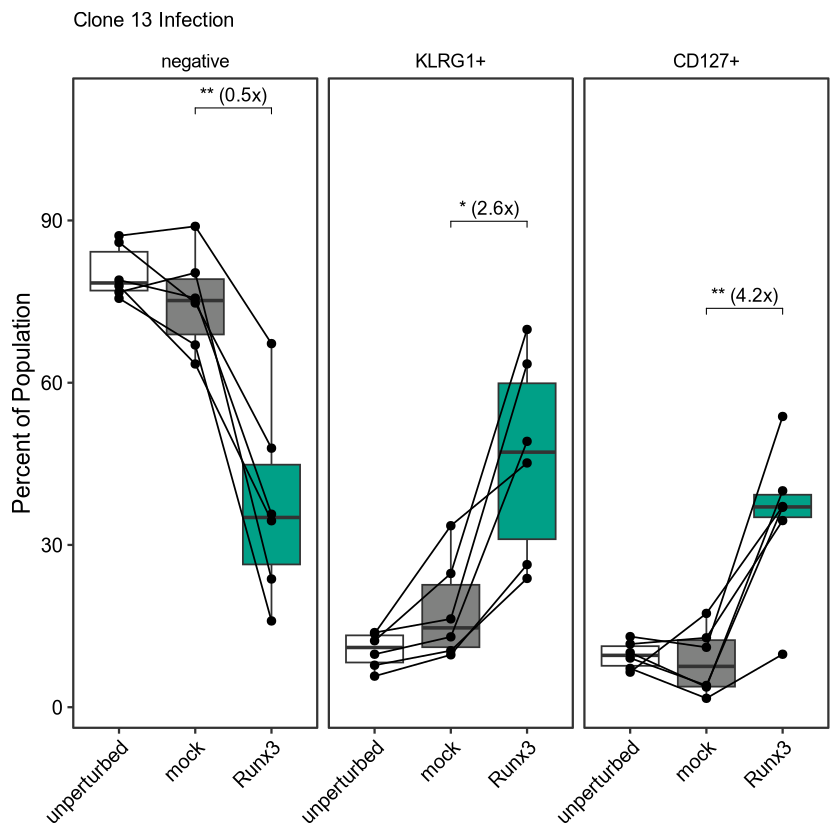

In [19]:
# Reduced figure panel: Clone 13 only, EE renamed "negative"
kaech_reduced <- kaech_subsets %>%
    filter(Group == "Clone 13") %>%
    mutate(
        Population = factor(
            recode(as.character(Population), "EE" = "negative"),
            levels = c("negative", "KLRG1+", "CD127+")
        )
    )

plot.stat.df <- plot_padj(
    data = kaech_reduced,
    comparisons = comparisons,
    y_col = "Percent",
    x_col = "Condition",
    facet_col = "Population",
    id_col = "ID",
    paired = TRUE,
    step_fraction = 0.15,
    min_step = 10
)

write.csv(plot.stat.df, paste0(output_folder, "/figStats-Kaech-Subsets-Reduced.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(kaech_reduced, aes(x = Condition, y = Percent, fill = Condition)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~Population) +
    scale_fill_manual(values = colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("Percent of Population") + ggtitle("Clone 13 Infection")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Kaech-Subsets-Reduced.pdf"),
    plot = p,
    width = 4,
    height = 4.5,
    units = "in"
)

### Armstrong vs Clone 13, unperturbed only

Unlike every other comparison in this notebook, this one is **unpaired**: Armstrong and Clone 13 unperturbed mice are different animals, not the same mouse measured twice.

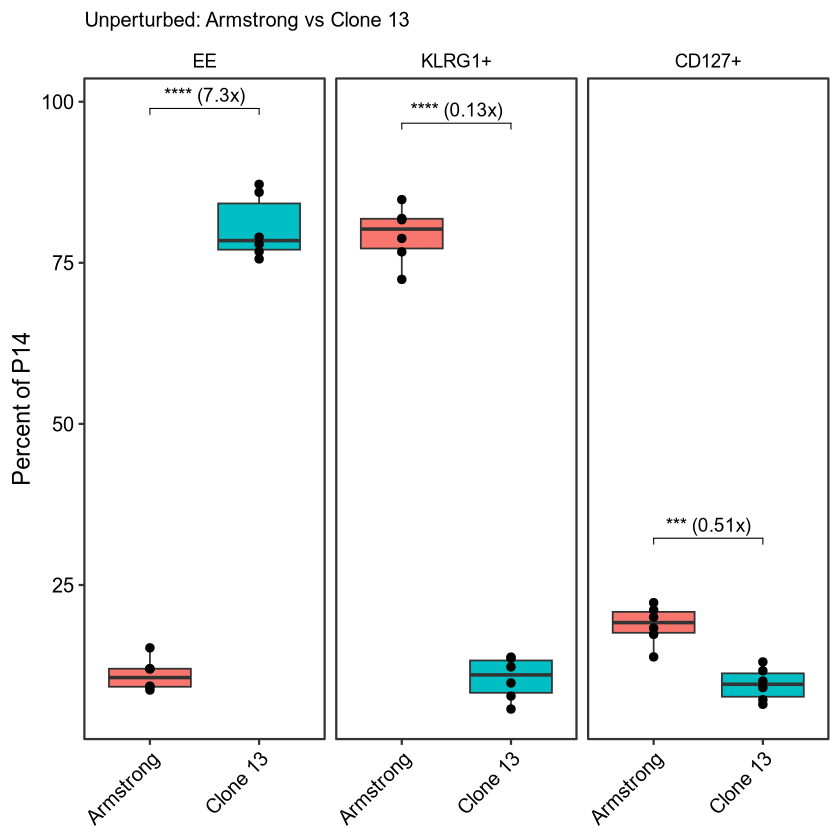

In [12]:
kaech_unperturbed <- kaech_subsets %>%
    filter(Condition == "unperturbed")

# Unpaired comparison: Armstrong and Clone 13 unperturbed mice are
# different animals, so paired = FALSE and no id_col/geom_line pairing
plot.stat.df <- plot_padj(
    data = kaech_unperturbed,
    comparisons = list(c("Armstrong", "Clone 13")),
    y_col = "Percent",
    x_col = "Group",
    facet_col = "Population",
    paired = FALSE,
    step_fraction = 0.15,
    min_step = 10
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-Kaech-Subsets-ArmstrongVsClone13-unperturbed.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(kaech_unperturbed, aes(x = Group, y = Percent, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_wrap(~Population) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("Percent of P14") + ggtitle("Unperturbed: Armstrong vs Clone 13")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Kaech-Subsets-ArmstrongVsClone13-unperturbed.pdf"),
    plot = p,
    width = 5,
    height = 4.5,
    units = "in"
)

### CX3CR1 status of KLRG1+ cells

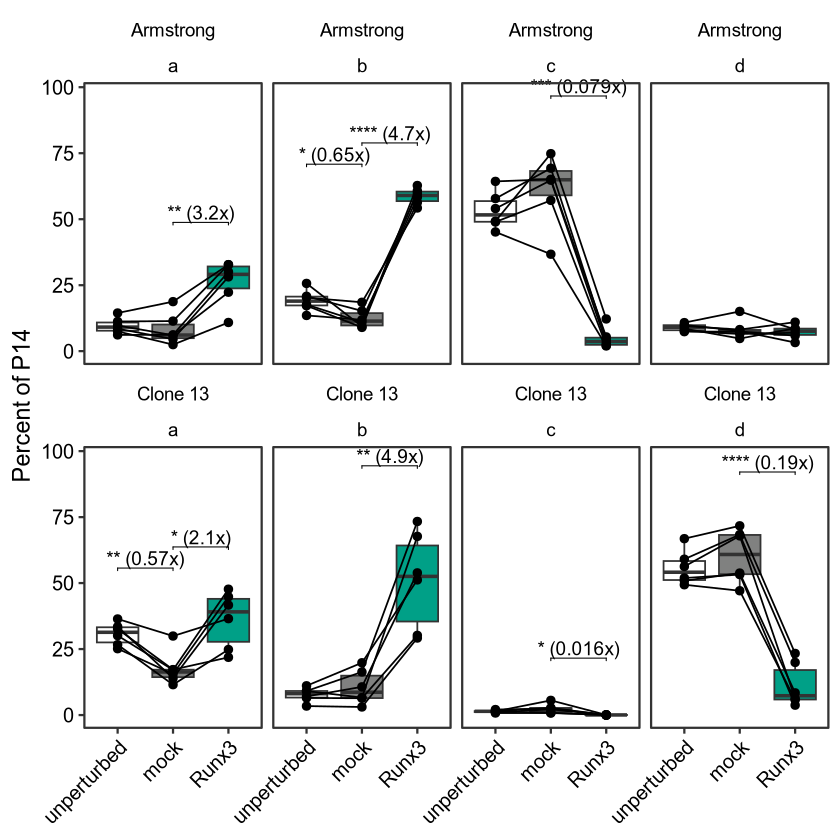

In [13]:
klr <- all.data %>%
    filter(Population %in% c("TcmKLRG1", "NonterminalKLRG1", "TerminalKLRG1", "ExhKLRG1")) %>%
    mutate(Population = factor(
        recode(Population,
            "TcmKLRG1" = "a", "NonterminalKLRG1" = "b",
            "TerminalKLRG1" = "c", "ExhKLRG1" = "d"),
        levels = c("a", "b", "c", "d")
    ))

plot.stat.df <- lapply(c("Armstrong", "Clone 13"), function(grp) {
    plot_padj(
        data = klr %>% filter(Group == grp),
        comparisons = comparisons,
        y_col = "Percent",
        x_col = "Condition",
        facet_col = "Population",
        id_col = "ID",
        paired = TRUE,
        step_fraction = 0.15,
        min_step = 8
    ) %>% mutate(Group = grp)
}) %>% bind_rows()

write.csv(plot.stat.df, paste0(output_folder, "/stats-Terminal-Subsets.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(klr, aes(x = Condition, y = Percent, fill = Condition)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~Group + Population, ncol = 4) +
    scale_fill_manual(values = colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("Percent of P14")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Terminal-Subsets.pdf"),
    plot = p,
    width = 12,
    height = 7,
    units = "in"
)

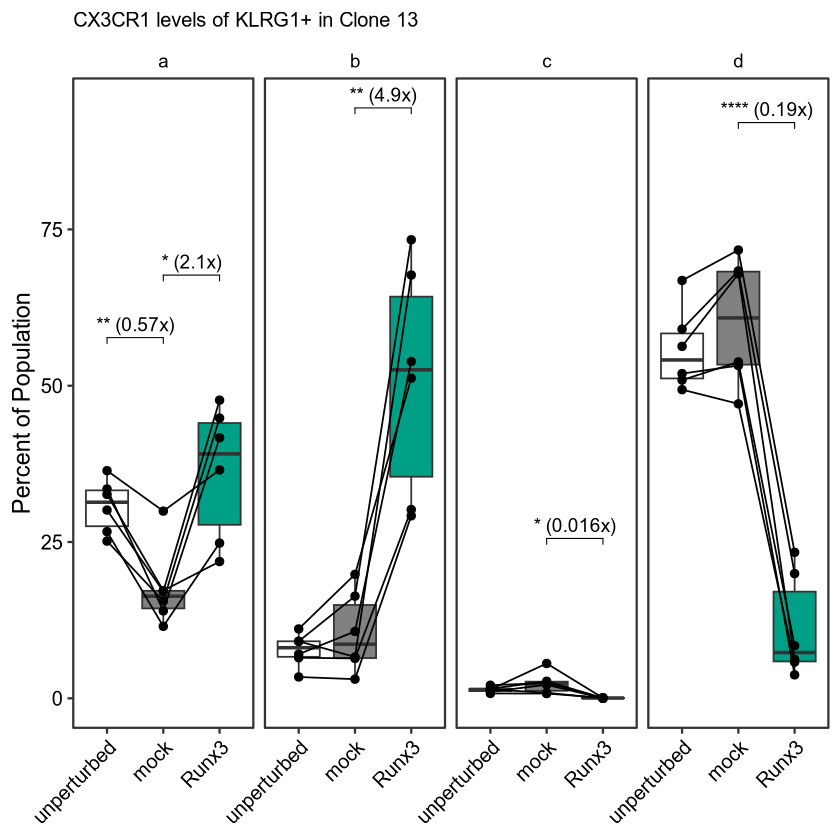

In [20]:
# Reduced figure panel: Clone 13 only
klr_reduced <- klr %>%
    filter(Group == "Clone 13")

plot.stat.df <- plot_padj(
    data = klr_reduced,
    comparisons = comparisons,
    y_col = "Percent",
    x_col = "Condition",
    facet_col = "Population",
    id_col = "ID",
    paired = TRUE,
    step_fraction = 0.15,
    min_step = 10
)

write.csv(plot.stat.df, paste0(output_folder, "/figStats-Terminal-Subsets-Reduced.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(klr_reduced, aes(x = Condition, y = Percent, fill = Condition)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~Population, ncol = 4) +
    scale_fill_manual(values = colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("Percent of Population") + ggtitle("CX3CR1 levels of KLRG1+ in Clone 13")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Terminal-Subsets-Reduced.pdf"),
    plot = p,
    width = 4,
    height = 4.5,
    units = "in"
)

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


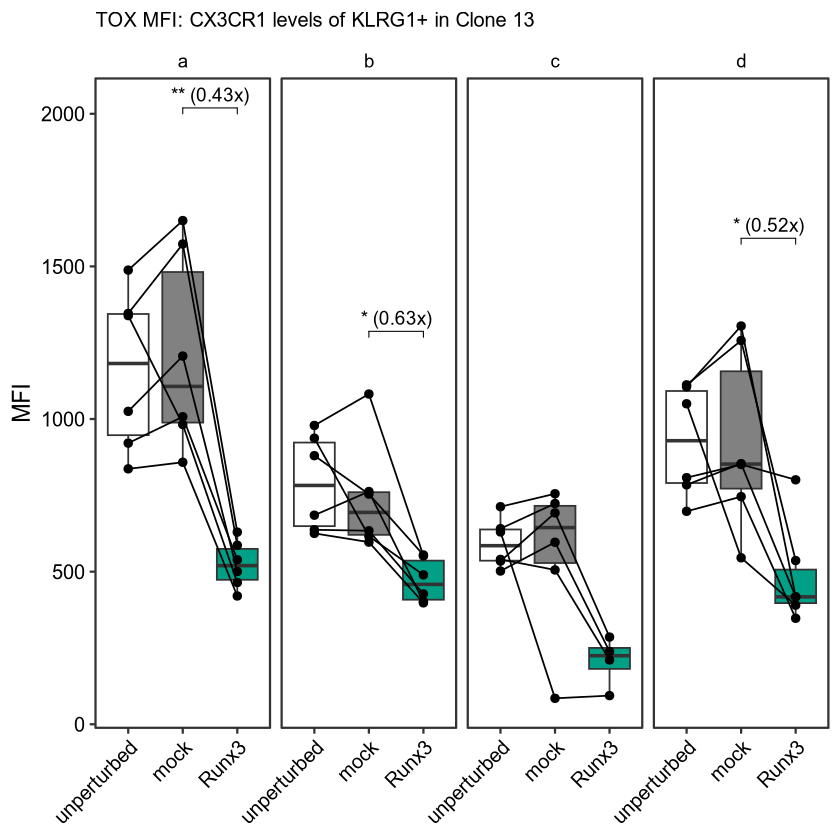

In [15]:
# TOX MFI in the same Clone 13 a/b/c/d subsets, paired like the Percent panel above
plot.stat.df <- plot_padj(
    data = klr_reduced,
    comparisons = comparisons,
    y_col = "mfi.TOX",
    x_col = "Condition",
    facet_col = "Population",
    id_col = "ID",
    paired = TRUE,
    step_fraction = 0.15,
    min_step = 20
)

write.csv(plot.stat.df, paste0(output_folder, "/figStats-Terminal-Subsets-Reduced-TOXmfi.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(klr_reduced, aes(x = Condition, y = mfi.TOX, fill = Condition)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~Population, ncol = 4) +
    scale_fill_manual(values = colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("MFI") + ggtitle("TOX MFI: CX3CR1 levels of KLRG1+ in Clone 13")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Terminal-Subsets-Reduced-TOXmfi.pdf"),
    plot = p,
    width = 6,
    height = 5,
    units = "in"
)

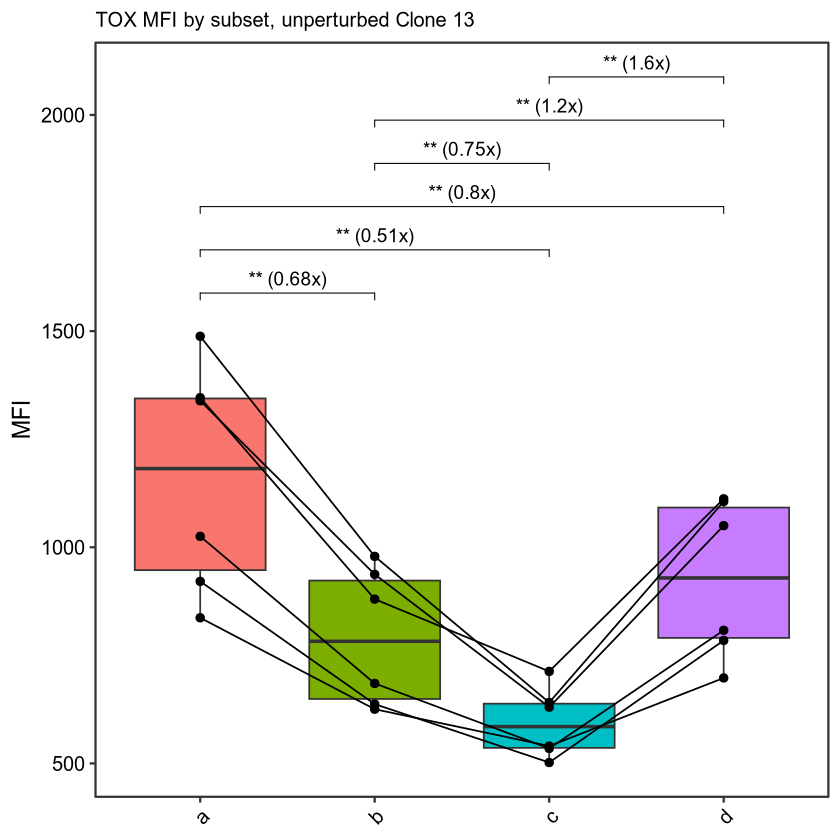

In [16]:
klr_unperturbed_clone13 <- klr_reduced %>%
    filter(Condition == "unperturbed")

# Pairwise comparisons across all four subsets
population_comparisons <- list(
    c("a", "b"), c("a", "c"), c("a", "d"),
    c("b", "c"), c("b", "d"), c("c", "d")
)

# Paired: same mouse compared across subsets, no facet needed (single Condition)
plot.stat.df <- plot_padj(
    data = klr_unperturbed_clone13,
    comparisons = population_comparisons,
    y_col = "mfi.TOX",
    x_col = "Population",
    id_col = "ID",
    paired = TRUE,
    step_fraction = 0.1,
    min_step = 100
)

write.csv(plot.stat.df, paste0(output_folder, "/figStats-Terminal-Subsets-Reduced-TOXmfi-unperturbed-byPopulation.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(klr_unperturbed_clone13, aes(x = Population, y = mfi.TOX, fill = Population)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    geom_line(aes(group = ID)) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("MFI") + ggtitle("TOX MFI by subset, unperturbed Clone 13")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Terminal-Subsets-Reduced-TOXmfi-unperturbed-byPopulation.pdf"),
    plot = p,
    width = 5,
    height = 7,
    units = "in"
)

### TOX MFI across subsets, unperturbed Clone 13

Compare TOX MFI among the four KLRG1×CX3CR1 subsets (a/b/c/d) within the same mice, unperturbed condition only. Paired: same mouse across subsets.

### Armstrong vs Clone 13, unperturbed only

Again unpaired: different mice.

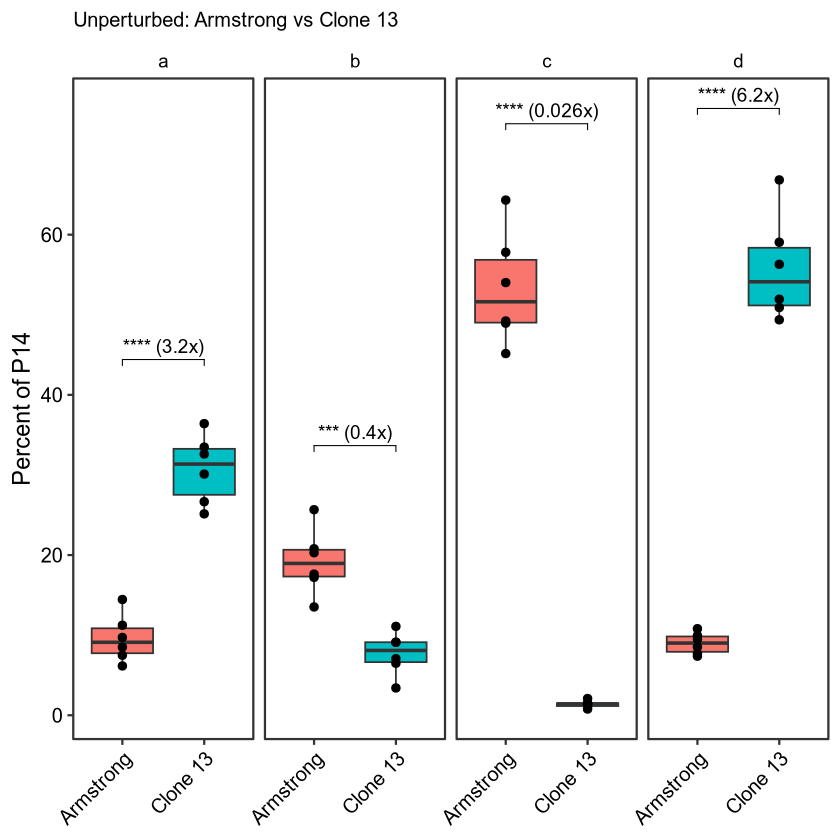

In [17]:
klr_unperturbed <- klr %>%
    filter(Condition == "unperturbed")

# Unpaired comparison: different mice
plot.stat.df <- plot_padj(
    data = klr_unperturbed,
    comparisons = list(c("Armstrong", "Clone 13")),
    y_col = "Percent",
    x_col = "Group",
    facet_col = "Population",
    paired = FALSE,
    step_fraction = 0.15,
    min_step = 8
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-Terminal-Subsets-ArmstrongVsClone13-unperturbed.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(klr_unperturbed, aes(x = Group, y = Percent, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_wrap(~Population, ncol = 4) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("Percent of P14") + ggtitle("Unperturbed: Armstrong vs Clone 13")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Terminal-Subsets-ArmstrongVsClone13-unperturbed.pdf"),
    plot = p,
    width = 10,
    height = 4.5,
    units = "in"
)